In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("tracks2026.csv")
df_original = df # Safety measure for manipulation of data

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


In [3]:

print(df['explicit'].dtype)
print(df['explicit'].unique())

bool
[False  True]


In [4]:
# Attempting to remove NA values from the dataset, there seems to be a pattern of if there are N/A values for a variable it is 40, 
# I am going to try to find if the N/A's are all in the same 40 rows, I believe I can just remove those rows if that is the case


# Count N/A values per row
na_per_row = df.isnull().sum(axis=1)

# Find rows with at least one N/A
rows_with_na = na_per_row[na_per_row > 0]

print("Statistics for rows with N/A values:")
print(f"Number of rows with at least 1 N/A: {len(rows_with_na)}")
print(f"Average N/A's per affected row: {rows_with_na.mean():.2f}")
print(f"\nDistribution of N/A counts in affected rows:")
print(rows_with_na.value_counts().sort_index())
print(f"\nHypothesis check - Do all N/A's cluster in same rows?")
print(f"Max N/A's in a single row: {rows_with_na.max()}")
print(f"Total unique rows with N/A: {len(rows_with_na)}")
print(f"Total N/A values in dataset: {df.isnull().sum().sum()}")

Statistics for rows with N/A values:
Number of rows with at least 1 N/A: 40
Average N/A's per affected row: 4.97

Distribution of N/A counts in affected rows:
4     1
5    39
Name: count, dtype: int64

Hypothesis check - Do all N/A's cluster in same rows?
Max N/A's in a single row: 5
Total unique rows with N/A: 40
Total N/A values in dataset: 199


All of the data rows with non applicaples seem to fall within the same 40 rows.

Seeing this issue I believe we could remove those 40 data rows and still have a strong model.

I will remove those 40 data rows now.

In [5]:
# Remove all rows with NA values
df = df.dropna()
df = df.drop(['track_id'], axis=1)

print(f"Dataset shape after removing NA values: {df.shape}")
print(f"Original data set with no NA values removed: {df_original.shape}")
print(f"Rows removed: {len(df_original) - len(df)}")
print(f"\nVerification - Missing values remaining: {df.isnull().sum().sum()}")

Dataset shape after removing NA values: (1960, 16)
Original data set with no NA values removed: (2000, 17)
Rows removed: 40

Verification - Missing values remaining: 0


Reviewing the document for Exploritory Data Analysis recommends Log Transformation and Standard Scaler for acousticness and valence, and Log Transfer for Robust Scaler for all other columns, I will set up and apply those to the data

In [6]:
from sklearn.preprocessing import RobustScaler, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Define column groups
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature', 'explicit']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'popularity', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df.columns if col not in continuous_numerical]

# Split outlier columns into negative and positive value groups
outlier_cols_neg = [col for col in outlier_cols if df[col].min() < 0]
outlier_cols_pos = [col for col in outlier_cols if df[col].min() >= 0]

# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p)),
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([
     ('log', FunctionTransformer(func=np.log1p)),
     ('scaler', RobustScaler())
])

# Sanity check for different columns
print("Passthrough columns:")
print(passthrough_cols)
print("\nNo outlier cols:")
print(no_outlier_cols)
print("\nOutlier cols negative:")
print(outlier_cols_neg)
print("\nOutlier cols positive:")
print(outlier_cols_pos)

# Combined preprocessor with explicit remainder handling
preprocessor = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
    ],
    remainder='passthrough'
)

Passthrough columns:
['explicit', 'key', 'mode', 'time_signature', 'track_genre']

No outlier cols:
['valence', 'popularity', 'acousticness']

Outlier cols negative:
['loudness']

Outlier cols positive:
['duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo']


Succesfully able to seperate each column into their respective attributes to accurately apply the log transformations and scalers.

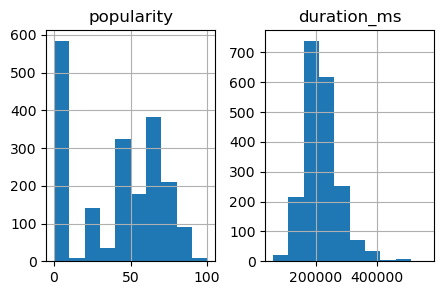

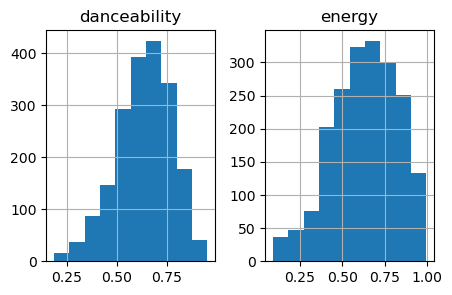

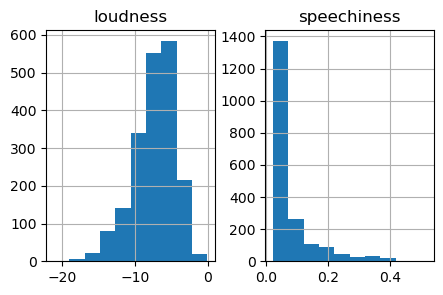

In [7]:
df[['popularity','duration_ms']].hist(figsize=(5,3)) # Testing catagorical numerical variables, 
df[['danceability', 'energy']].hist(figsize=(5,3))
df[['loudness', 'speechiness']].hist(figsize=(5,3))
plt.show()

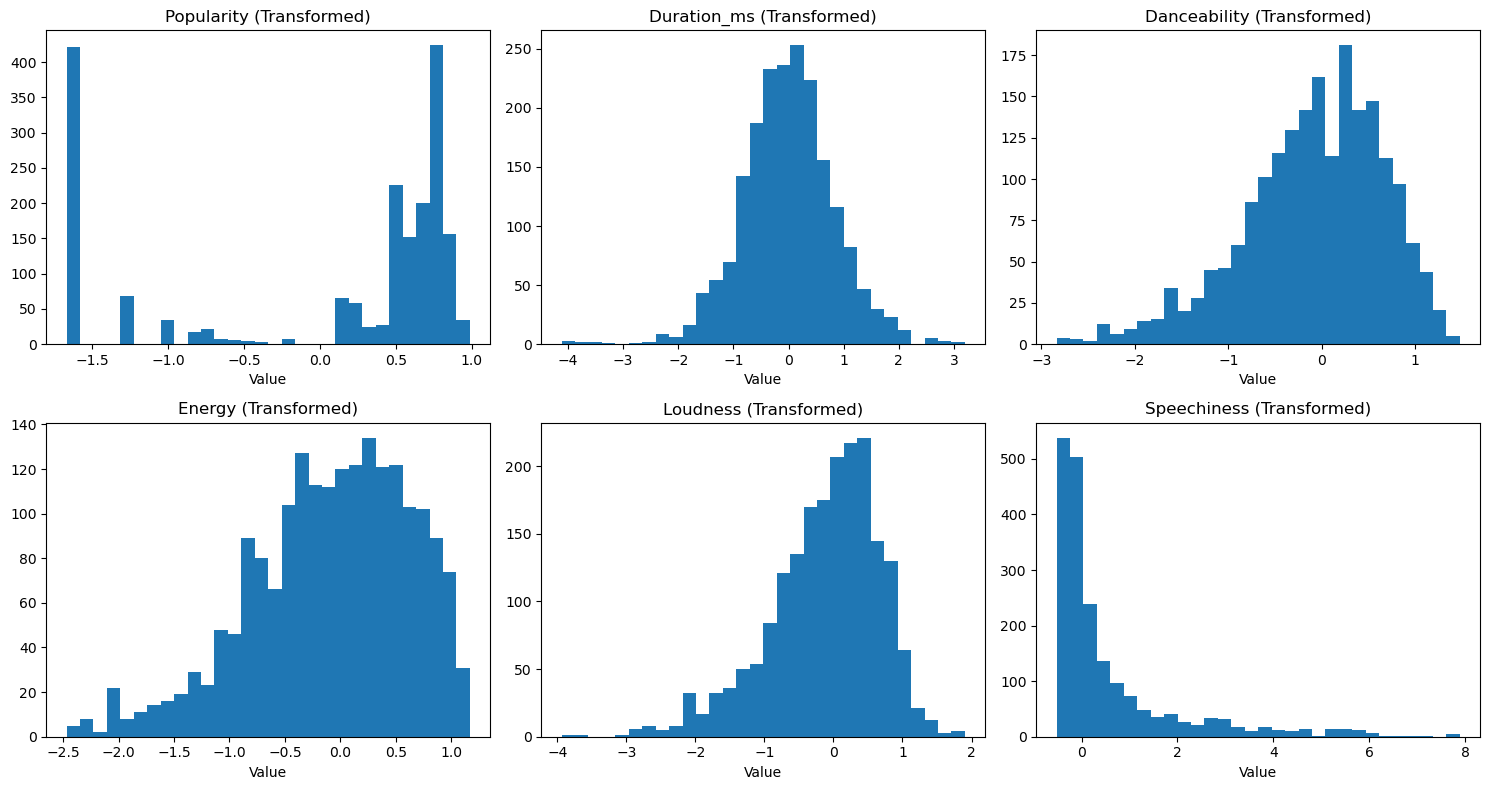


Transformed data statistics:
         popularity  duration_ms  danceability      energy     loudness  \
count   1960.000000   1960.00000   1960.000000  1960.00000  1960.000000   
unique    89.000000   1629.00000    541.000000   668.00000  1542.000000   
top       -1.669934     -0.85068      0.005246     0.08731     0.350897   
freq     422.000000     15.00000     19.000000    19.00000    15.000000   

        speechiness  
count    1960.00000  
unique    695.00000  
top         0.11605  
freq       17.00000  


In [8]:
# Apply preprocessing and create transformed dataframe
transformed_array = preprocessor.fit_transform(df)

# Manually reconstruct column order
output_cols = (no_outlier_cols + outlier_cols_neg + outlier_cols_pos + passthrough_cols)

df_transformed = pd.DataFrame(
    transformed_array,
    columns=output_cols
)
# Plot the TRANSFORMED data
fig, axes = plt.subplots(2, 3, figsize=(15, 8))


# Popularity and duration_ms (after log + StandardScaler)
axes[0, 0].hist(df_transformed['popularity'], bins=30)
axes[0, 0].set_title('Popularity (Transformed)')
axes[0, 0].set_xlabel('Value')

axes[0, 1].hist(df_transformed['duration_ms'], bins=30)
axes[0, 1].set_title('Duration_ms (Transformed)')
axes[0, 1].set_xlabel('Value')

# Danceability and energy (after log + RobustScaler)
axes[0, 2].hist(df_transformed['danceability'], bins=30)
axes[0, 2].set_title('Danceability (Transformed)')
axes[0, 2].set_xlabel('Value')

axes[1, 0].hist(df_transformed['energy'], bins=30)
axes[1, 0].set_title('Energy (Transformed)')
axes[1, 0].set_xlabel('Value')

# Loudness (RobustScaler only) and speechiness (log + RobustScaler)
axes[1, 1].hist(df_transformed['loudness'], bins=30)
axes[1, 1].set_title('Loudness (Transformed)')
axes[1, 1].set_xlabel('Value')

axes[1, 2].hist(df_transformed['speechiness'], bins=30)
axes[1, 2].set_title('Speechiness (Transformed)')
axes[1, 2].set_xlabel('Value')

plt.tight_layout()
plt.show()

print("\nTransformed data statistics:")
print(df_transformed[['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness']].describe())

Now that the data has been transformed I am going to one hot encode track_genre and convert explicit from boolean to ones and zeros

In [15]:
# Replacing explicit with ones and zeros
scale_mapper = {
    "False": 0,
    "True": 1,
}

df_transformed['explicit'] = df_transformed['explicit'].replace(scale_mapper)

# One hot encoding track_genre
df_transformed = pd.get_dummies(df_transformed, columns=['track_genre'],
                        drop_first=True)

/var/folders/d6/mzx1sy1568j4ryx75qh_hvyc0000gn/T/ipykernel_64131/3143737466.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_transformed['explicit'] = df_transformed['explicit'].replace(scale_mapper)


In [16]:
# Check for missing values
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Also check info
print("\nDataFrame info:")
df_transformed.info()


Total missing values: 0

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1960 entries, 0 to 1959
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   valence                1960 non-null   object
 1   popularity             1960 non-null   object
 2   acousticness           1960 non-null   object
 3   loudness               1960 non-null   object
 4   duration_ms            1960 non-null   object
 5   danceability           1960 non-null   object
 6   energy                 1960 non-null   object
 7   speechiness            1960 non-null   object
 8   instrumentalness       1960 non-null   object
 9   liveness               1960 non-null   object
 10  tempo                  1960 non-null   object
 11  explicit               1960 non-null   bool  
 12  key                    1960 non-null   object
 13  mode                   1960 non-null   object
 14  time_signature         1960 no

In [17]:
df_transformed.head()



,valence,popularity,acousticness,loudness,duration_ms,danceability,energy,speechiness,instrumentalness,liveness,tempo,explicit,key,mode,time_signature,track_genre_indie-pop,track_genre_pop,track_genre_r-n-b,track_genre_synth-pop
0,0.082296,0.522709,0.448524,0.953983,-0.125232,-0.201751,-0.343045,-0.418492,-0.010363,0.249932,0.528641,False,10,1,3,False,False,True,False
1,1.066102,0.882222,-0.659722,0.650076,-0.038716,0.651736,-0.114681,0.138373,0.025675,0.10001,-0.467142,False,3,0,4,False,True,False,False
2,1.486579,0.583396,0.003012,-0.589184,0.708688,0.758137,-0.118417,-0.331233,0.006187,1.429284,-0.012694,False,2,0,4,False,False,False,True
3,0.770855,-1.669934,-0.915276,0.94731,-0.317469,-0.342557,0.642412,2.783162,-0.010363,1.07925,-0.727684,False,9,1,4,True,False,False,False
4,-0.098867,0.482969,-0.039238,0.068956,0.964428,0.304195,0.247682,-0.075669,0.013611,-0.595249,0.2465,False,4,0,4,False,False,False,True


According to EDA valance, popularity and acousticness don't have outliers

In [11]:
# Remove this for now as it seems rendundant compared to what was already done in the EDA notebook, we can always add it back in if we need to
'''# Identify columns with outliers (excluding valence, popularity, acousticness)
outlier_columns = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ['valence', 'popularity', 'acousticness']]

# Function to detect outliers using IQR
def is_outlier(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

# Create a mask for rows with outliers in any of the outlier_columns
outlier_mask = df[outlier_columns].apply(is_outlier).any(axis=1)

# Split the dataset
df_without_outliers = df[~outlier_mask]
df_with_outliers = df[outlier_mask]

print(f"Original dataset size: {len(df)}")
print(f"Dataset without outliers: {len(df_without_outliers)}")
print(f"Dataset with outliers: {len(df_with_outliers)}")

# Check min values for no_outlier_cols
print("Min values for no_outlier_cols:")
print(df[['valence', 'popularity', 'acousticness']].min()) '''


'# Identify columns with outliers (excluding valence, popularity, acousticness)\noutlier_columns = [col for col in df.select_dtypes(include=[np.number]).columns if col not in [\'valence\', \'popularity\', \'acousticness\']]\n\n# Function to detect outliers using IQR\ndef is_outlier(series):\n    Q1 = series.quantile(0.25)\n    Q3 = series.quantile(0.75)\n    IQR = Q3 - Q1\n    lower_bound = Q1 - 1.5 * IQR\n    upper_bound = Q3 + 1.5 * IQR\n    return (series < lower_bound) | (series > upper_bound)\n\n# Create a mask for rows with outliers in any of the outlier_columns\noutlier_mask = df[outlier_columns].apply(is_outlier).any(axis=1)\n\n# Split the dataset\ndf_without_outliers = df[~outlier_mask]\ndf_with_outliers = df[outlier_mask]\n\nprint(f"Original dataset size: {len(df)}")\nprint(f"Dataset without outliers: {len(df_without_outliers)}")\nprint(f"Dataset with outliers: {len(df_with_outliers)}")\n\n# Check min values for no_outlier_cols\nprint("Min values for no_outlier_cols:")\nprint

In [12]:
'''# Check min/max for all outlier columns to identify positive vs negative
print("Min and Max values for outlier columns:")
print(df[outlier_columns].describe().loc[['min', 'max']])
print("\n\nColumns with negative values:")
for col in outlier_columns:
    if df[col].min() < 0:
        print(f"{col}: min={df[col].min():.4f}, max={df[col].max():.4f}")

print("\n\nColumns with only positive values:")
for col in outlier_columns:
    if df[col].min() >= 0:
        print(f"{col}: min={df[col].min():.4f}, max={df[col].max():.4f}")'''

'# Check min/max for all outlier columns to identify positive vs negative\nprint("Min and Max values for outlier columns:")\nprint(df[outlier_columns].describe().loc[[\'min\', \'max\']])\nprint("\n\nColumns with negative values:")\nfor col in outlier_columns:\n    if df[col].min() < 0:\n        print(f"{col}: min={df[col].min():.4f}, max={df[col].max():.4f}")\n\nprint("\n\nColumns with only positive values:")\nfor col in outlier_columns:\n    if df[col].min() >= 0:\n        print(f"{col}: min={df[col].min():.4f}, max={df[col].max():.4f}")'

In [13]:
'''# Apply preprocessing to the datasets
# Fit and transform separately for each dataset to ensure proper scaling

df_without_outliers_transformed = pd.DataFrame(
    preprocessor.fit_transform(df_without_outliers),
    columns=df.columns
)

df_with_outliers_transformed = pd.DataFrame(
    preprocessor.fit_transform(df_with_outliers),
    columns=df.columns
)

# Now df_without_outliers_transformed and df_with_outliers_transformed are preprocessed'''

'# Apply preprocessing to the datasets\n# Fit and transform separately for each dataset to ensure proper scaling\n\ndf_without_outliers_transformed = pd.DataFrame(\n    preprocessor.fit_transform(df_without_outliers),\n    columns=df.columns\n)\n\ndf_with_outliers_transformed = pd.DataFrame(\n    preprocessor.fit_transform(df_with_outliers),\n    columns=df.columns\n)\n\n# Now df_without_outliers_transformed and df_with_outliers_transformed are preprocessed'

In [14]:
'''df[['popularity','duration_ms']].hist()
plt.show()
df[['danceability', 'energy']].hist()
plt.show()
df[['loudness', 'speechiness']].hist()
plt.show()'''

"df[['popularity','duration_ms']].hist()\nplt.show()\ndf[['danceability', 'energy']].hist()\nplt.show()\ndf[['loudness', 'speechiness']].hist()\nplt.show()"